# Creating a function that can take a simulation and calculate the light curve from it

In [1]:
# Importing crap
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import scipy.ndimage

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics as IRSC

import VBMicrolensing
import MulensModel as mm
import numexpr

import astropy.units as u
import astropy.constants as c

import csv

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['figure.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['mathtext.fontset'] = 'cm'

In [2]:
#%% Defining some useful functions
def log_array(min_pow, max_pow):
    powers = np.arange(min_pow, max_pow + 1)
    base_values = np.array([1, 3])
    
    # Use broadcasting to create the sequence
    pos_arr = np.concatenate([base_values * (10.0**p) for p in powers])

    neg_arr = -pos_arr[::-1]

    return np.concatenate([neg_arr, np.array([0]), pos_arr])

def colors_by_log(arr):
    colors = []
    for val in arr:
        if val < 0:
            colors.append('blue')
        elif val == 0:
            colors.append('green')
        elif val > 0:
            colors.append('red')
    return colors

def half_decade_levels(data, num_steps=6, min_steps=3):
    '''Build symmetric half-decade contour levels adapted to the data range.

    Levels follow the base ``[1, 3]`` pattern (..., 1e-2, 3e-2, 1e-1, 3e-1,
    1, 3, ...) so each decade contributes two steps. The largest level is
    anchored to the biggest such step at or below the data's maximum absolute
    value, guaranteeing the outer contours are actually reached. ``num_steps``
    levels (>= ``min_steps``) are then placed per sign, with a 0 contour.
    '''
    num_steps = max(num_steps, min_steps)

    base = (1.0, 3.0)

    def value_at(k):
        # Maps integer index k -> base[1, 3] level, e.g. k=0 -> 1, k=1 -> 3,
        # k=2 -> 10, k=-1 -> 0.3, k=-2 -> 0.1 (floor division handles k<0).
        return base[k % 2] * 10.0 ** (k // 2)

    finite = data[np.isfinite(data)]
    max_abs = np.max(np.abs(finite)) if finite.size else 0.0

    if not np.isfinite(max_abs) or max_abs <= 0:
        # Flat / degenerate map: fall back to a sane default range (top -> 0.3).
        top = -1
    else:
        # Largest [1, 3] step at/below the data max (overshoot, then back off).
        top = int(np.ceil(2 * np.log10(max_abs)))
        while value_at(top) > max_abs:
            top -= 1

    # Descending indices top, top-1, ... -> ascending positive levels.
    pos = np.sort([value_at(top - j) for j in range(num_steps)])
    neg = -pos[::-1]

    return np.concatenate([neg, [0.0], pos])

def linewidths_by_level(levels, min_lw=0.3, max_lw=1.3):
    '''Thicker lines for larger-magnitude contours, symmetric about 0.'''
    pos_levels = sorted({abs(v) for v in levels if v != 0})
    n = len(pos_levels)
    if n > 1:
        lw_map = {lv: min_lw + (max_lw - min_lw) * idx / (n - 1)
                    for idx, lv in enumerate(pos_levels)}
    elif n == 1:
        lw_map = {pos_levels[0]: max_lw}
    else:
        lw_map = {}

    lws = []
    for v in levels:
        if v == 0:
            lws.append((min_lw + max_lw) / 2)
        else:
            lws.append(lw_map[abs(v)])
    return lws

Importing test simulations

Plotting magnification map: 0.215 seconds
Plotting magnification map: 0.206 seconds


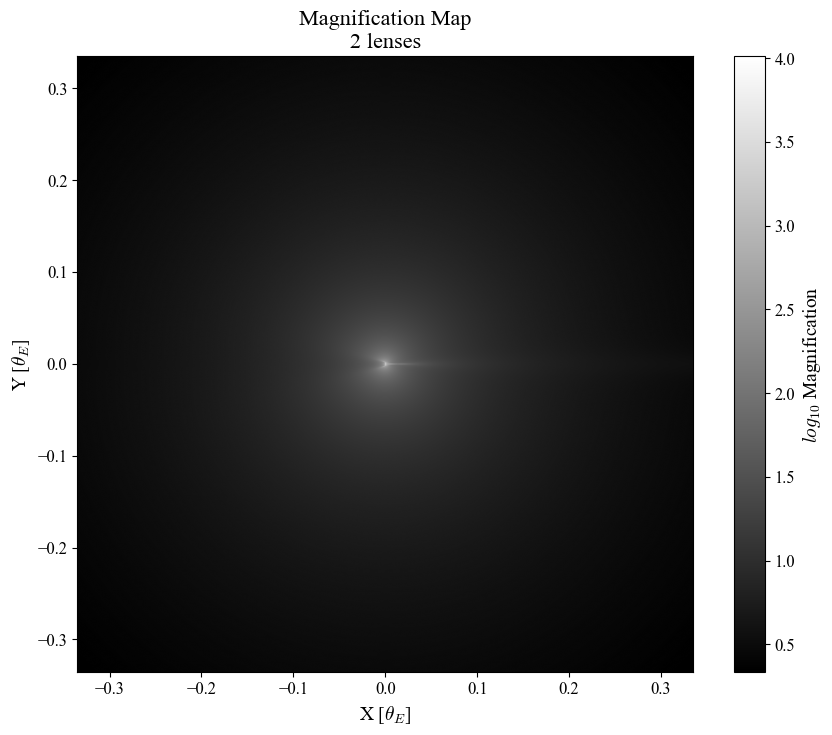

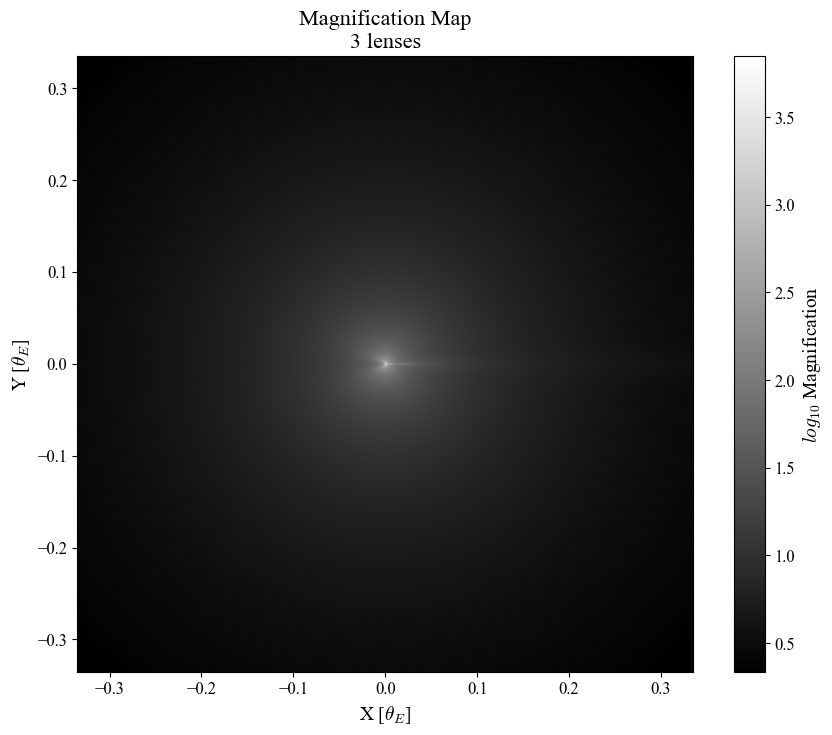

In [3]:
sun_jupiter = IRSC.caustic_reader('../../Unity/Simulations/Part_6_Multiplanet_Collection/sun_jupiter.pkl')
sun_jupiter.plot()

ang_width = sun_jupiter.ang_width
ang_res = sun_jupiter.ang_res

sun_jupiter_saturn = IRSC.caustic_reader('../../Unity/Simulations/Part_6_Multiplanet_Collection/sun_jupiter_saturn.pkl')
sun_jupiter_saturn.plot()

plt.show()

Convolving with a source profile

In [4]:
source_radius = 0.05

# Defining source profile
source_profile = IRSF.IRSFunctions.source_profile(ang_res=ang_res, profile_type='LD', rad=source_radius, LD=0.5)

# Convolving with source profile
sun_jupiter_convolved = sun_jupiter.convolve(source_profile=source_profile)
sun_jupiter_saturn_convolved = sun_jupiter_saturn.convolve(source_profile=source_profile)

100%|██████████| 687/687 [00:00<00:00, 1928.67it/s]


Convolving source profile with magnification map: 0.946 seconds
Convolving source profile with magnification map: 0.99 seconds


In [5]:
# Calculating fractional difference
frac_diff_map = (sun_jupiter_saturn_convolved - sun_jupiter_convolved) / sun_jupiter_convolved

Plotting the convolved brightness map

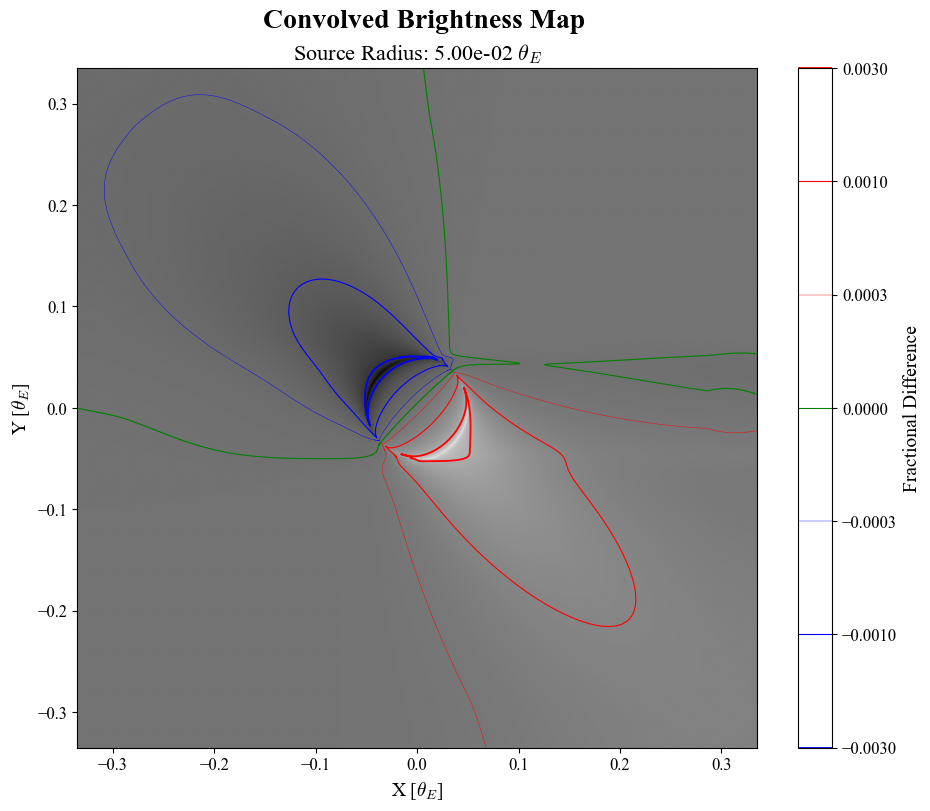

In [6]:
fig = plt.figure()
fig.set_constrained_layout(True)
ax = fig.add_subplot()

fig.suptitle('Convolved Brightness Map')
ax.set_title(f'Source Radius: {source_radius:.2e} $\\theta_E$')
        
plot = ax.imshow(frac_diff_map, 
                cmap='gray',
                extent=[-ang_width/2 - ang_res/2, ang_width/2 + ang_res/2, -ang_width/2 - ang_res/2, ang_width/2 + ang_res/2],
)
# Adapt contour levels to this map so lines are always visible, even
# when subtracting small planets shrinks the fractional deviations.
levels = half_decade_levels(frac_diff_map, num_steps=3, min_steps=3)

plot = ax.contour(np.flip(frac_diff_map, axis=0),
        levels=levels,
        colors=colors_by_log(levels),
        linewidths=linewidths_by_level(levels),
        extent=[-ang_width/2 - ang_res/2, ang_width/2 + ang_res/2, -ang_width/2 - ang_res/2, ang_width/2 + ang_res/2]
)

bar = plt.colorbar(plot)
bar.set_label('Fractional Difference')

ax.set_xlabel(r'X [$\theta_E$]')
ax.set_ylabel(r'Y [$\theta_E$]')

plt.show()

## Defining lightcurve function

In [7]:
# The light curve function now lives in the IRS library and is verified below.
# Call it via IRSF.IRSFunctions.lightcurve_calculator(map_array, ang_width, u_0, alpha, t_0=0, t_E=1).


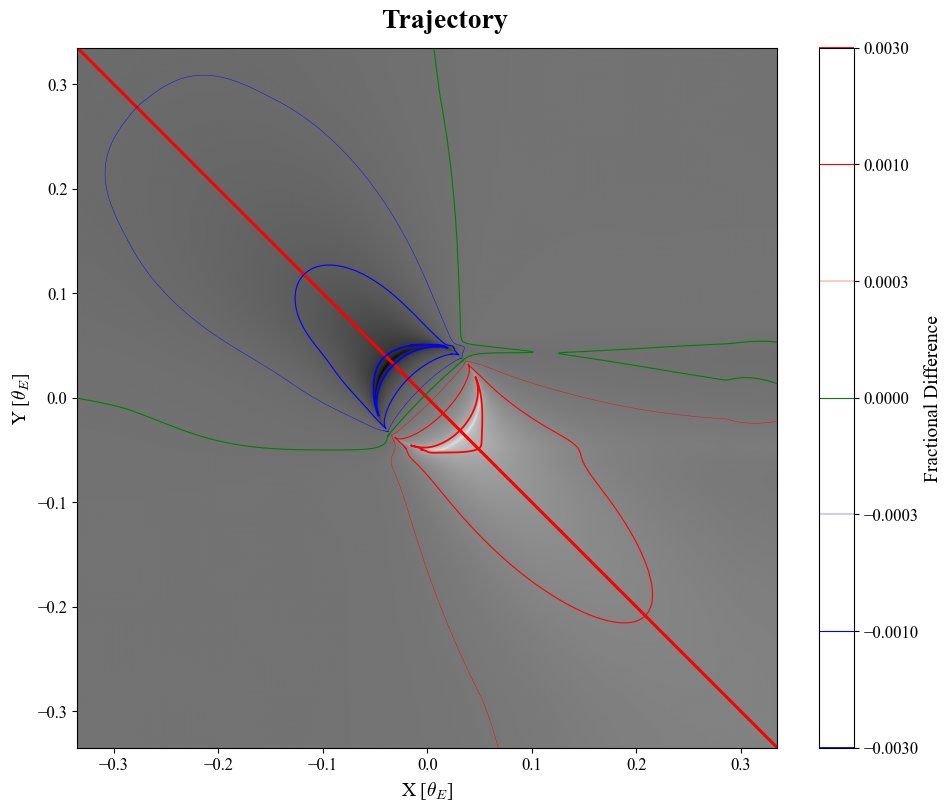

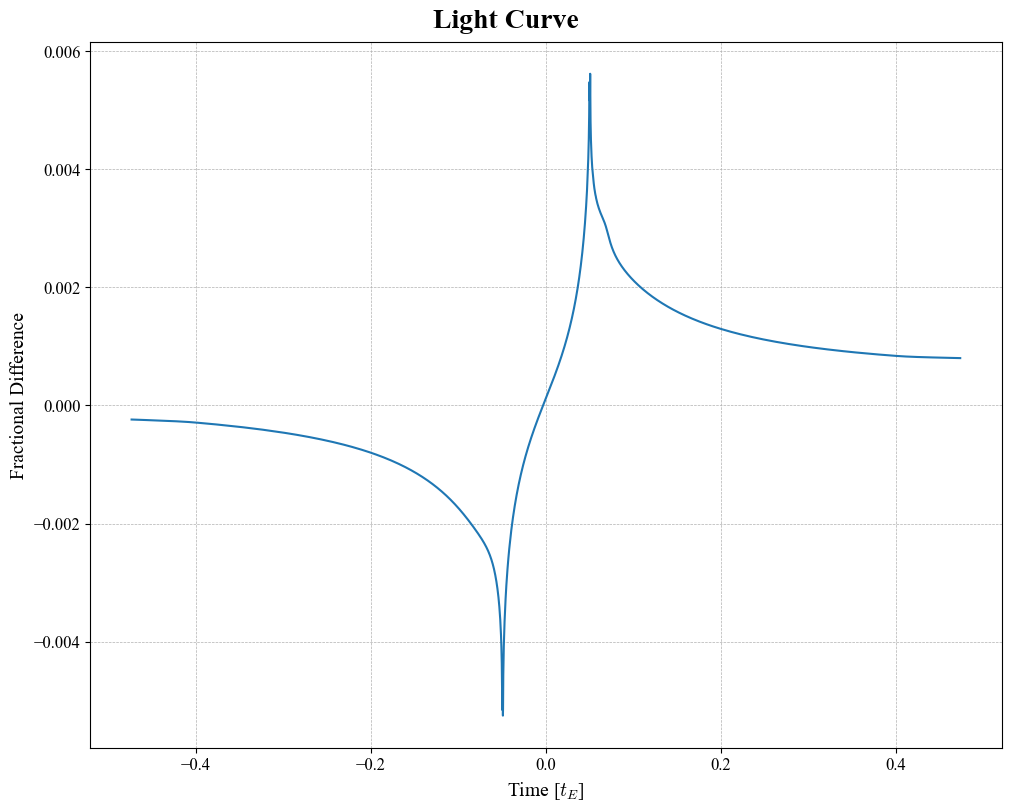

In [8]:
u_0 = 0
alpha = -45

times, values, (xs, ys) = IRSF.IRSFunctions.lightcurve_calculator(frac_diff_map, ang_width, u_0=u_0, alpha=alpha)

fig = plt.figure()
fig.set_constrained_layout(True)

fig.suptitle('Trajectory')
ax = fig.add_subplot()

plot = ax.imshow(frac_diff_map, 
                cmap='gray',
                extent=[-ang_width/2 - ang_res/2, ang_width/2 + ang_res/2, -ang_width/2 - ang_res/2, ang_width/2 + ang_res/2],
)
# Adapt contour levels to this map so lines are always visible, even
# when subtracting small planets shrinks the fractional deviations.
levels = half_decade_levels(frac_diff_map, num_steps=3, min_steps=3)

plot = ax.contour(np.flip(frac_diff_map, axis=0),
        levels=levels,
        colors=colors_by_log(levels),
        linewidths=linewidths_by_level(levels),
        extent=[-ang_width/2 - ang_res/2, ang_width/2 + ang_res/2, -ang_width/2 - ang_res/2, ang_width/2 + ang_res/2]
)

bar = plt.colorbar(plot)
bar.set_label('Fractional Difference')

ax.scatter(xs, ys, c='red', s=0.1)

ax.set_xlabel(r'X [$\theta_E$]')
ax.set_ylabel(r'Y [$\theta_E$]')

fig = plt.figure()
fig.set_constrained_layout(True)
ax = fig.add_subplot()

fig.suptitle('Light Curve')
ax.plot(times, values)

ax.grid(True, which='both', linestyle='--', linewidth=0.5)

ax.set_xlabel('Time [$t_E$]')
ax.set_ylabel('Fractional Difference')

plt.show()

Test 1 (x-ramp,  tests column/x mapping):   max|err| = 5.551115123125783e-17
Test 2 (y-ramp,  tests row/y orientation):  max|err| = 4.163336342344337e-17
Test 3 (radial Gaussian, tests u_0 + interp): max|err| = 0.013435513333125315

Closest-approach distance check: min sqrt(xs^2+ys^2) = 0.1  (should be ~ u_0 = 0.1 )


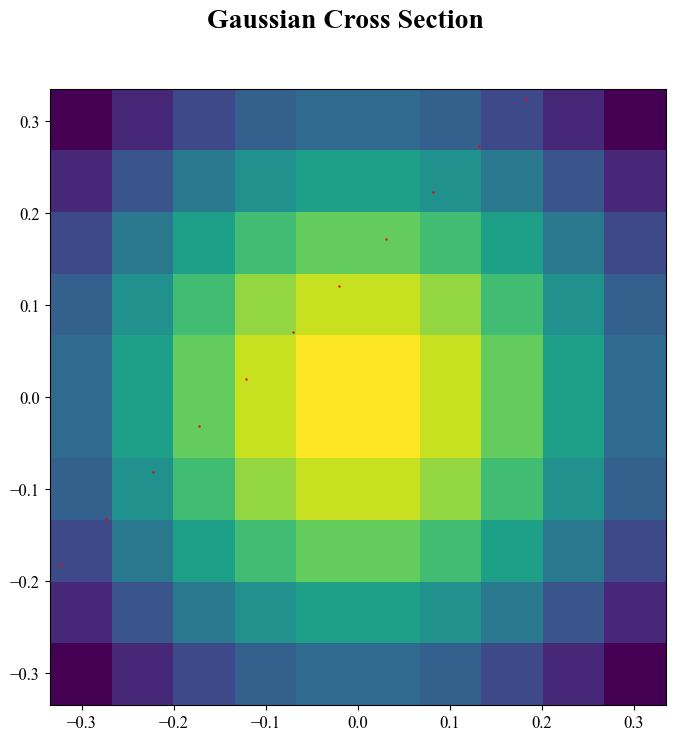

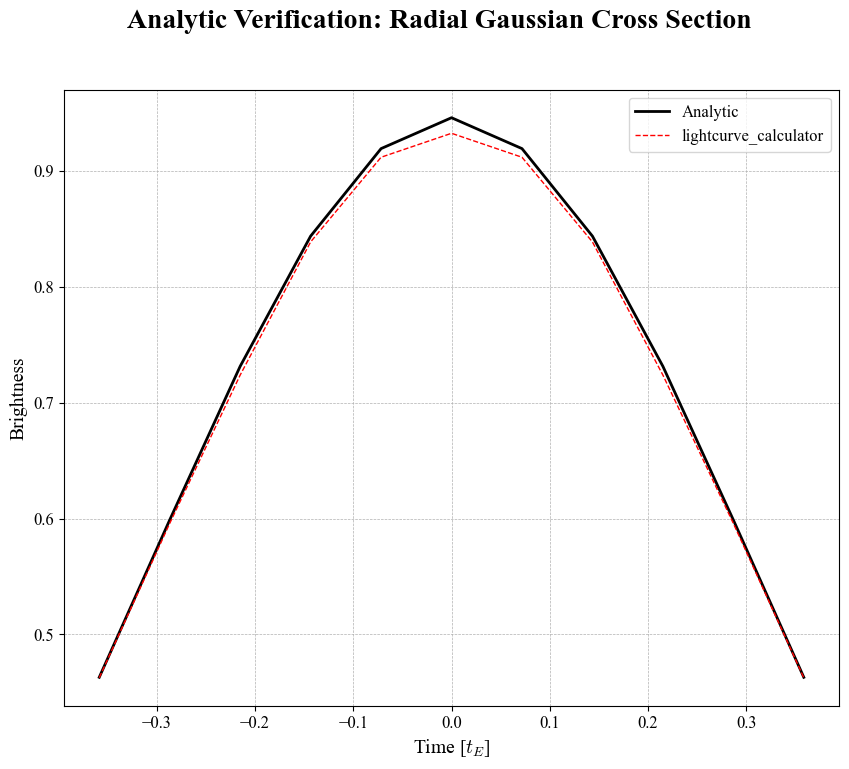

In [17]:
# =====================================================================
# Quantitative verification against analytic ground-truth maps
# =====================================================================
# Build synthetic maps whose value at every pixel is a known function of
# (x, y), sample them with the library lightcurve_calculator, and compare to the exact
# analytic value evaluated at the trajectory coordinates. This validates
# the coordinate mapping, the y-axis orientation, the impact parameter,
# and the interpolation accuracy all at once.

pixels = 10
ang_res_v = ang_width / (pixels - 1)

# Coordinate of each pixel, matching the function's inversion:
#   column c -> x = -W/2 + c * ang_res     (x increases with column)
#   row    r -> y = +W/2 - r * ang_res     (y DECREASES with row)
xv = -ang_width / 2 + np.arange(pixels) * ang_res_v
yv = ang_width / 2 - np.arange(pixels) * ang_res_v
X, Y = np.meshgrid(xv, yv)   # X[r, c], Y[r, c]

# Use a non-trivial trajectory so both axes and the offset are exercised.
u_0_test = 0.1
alpha_test = 45

# --- Test 1: map == x  -> recovered values must equal xs --------------
_, vals_x, (xs_t, ys_t) = IRSF.IRSFunctions.lightcurve_calculator(X, ang_width, u_0=u_0_test, alpha=alpha_test)
err_x = np.max(np.abs(vals_x - xs_t))

# --- Test 2: map == y  -> recovered values must equal ys (orientation)-
_, vals_y, _ = IRSF.IRSFunctions.lightcurve_calculator(Y, ang_width, u_0=u_0_test, alpha=alpha_test)
err_y = np.max(np.abs(vals_y - ys_t))

# --- Test 3: radial Gaussian -> values must equal exp(-(u_0^2+tau^2)/2s^2)
s = 0.3
G = np.exp(-(X**2 + Y**2) / (2 * s**2))
times_g, vals_g, _ = IRSF.IRSFunctions.lightcurve_calculator(G, ang_width, u_0=u_0_test, alpha=alpha_test)
# With t_0=0, t_E=1 the time axis equals tau, and r^2 = u_0^2 + tau^2.
expected_g = np.exp(-(u_0_test**2 + times_g**2) / (2 * s**2))
err_g = np.max(np.abs(vals_g - expected_g))

print('Test 1 (x-ramp,  tests column/x mapping):   max|err| =', err_x)
print('Test 2 (y-ramp,  tests row/y orientation):  max|err| =', err_y)
print('Test 3 (radial Gaussian, tests u_0 + interp): max|err| =', err_g)
print()
print('Closest-approach distance check: min sqrt(xs^2+ys^2) =',
      np.min(np.sqrt(xs_t**2 + ys_t**2)), ' (should be ~ u_0 =', u_0_test, ')')

fig, ax = plt.subplots()
fig.suptitle('Gaussian Cross Section')
ax.imshow(G, extent=[-ang_width/2, ang_width/2, -ang_width/2, ang_width/2],)
ax.scatter(xs_t, ys_t, c='red', s=0.5)

# Visual confirmation of the Gaussian test.
fig, ax = plt.subplots()
fig.suptitle('Analytic Verification: Radial Gaussian Cross Section')
ax.plot(times_g, expected_g, 'k-', lw=2, label='Analytic')
ax.plot(times_g, vals_g, 'r--', lw=1, label='lightcurve_calculator')
ax.set_xlabel('Time [$t_E$]')
ax.set_ylabel('Brightness')
ax.legend()
ax.grid(True, linestyle='--', linewidth=0.5)
plt.show()